# Malaria Cell Classification — End-to-End Machine Learning Pipeline

**Detecting *Plasmodium falciparum* parasites in segmented red blood cell images.**

---

## The problem

Malaria killed an estimated 597,000 people in 2023, the overwhelming majority of
them in sub-Saharan Africa. The diagnostic gold standard remains what it was a
century ago: a trained microscopist examines a Giemsa-stained blood smear and
counts parasites by eye. That method is accurate in expert hands and unreliable
outside them — it takes 20–30 minutes per slide, demands years of training, and
its accuracy degrades sharply with technician fatigue and workload.

This notebook builds the model behind an automated screening tool: given one
segmented red blood cell, decide whether it is **Parasitized** or **Uninfected**.

## What this notebook covers

| Section | Content |
|---|---|
| 1 | Data acquisition and integrity checks |
| 2 | Exploratory analysis — class balance, image geometry |
| 3 | Feature engineering and interpretation of 3 features |
| 4 | Preprocessing pipeline |
| 5 | Model architecture and optimization techniques |
| 6 | Hyperparameter tuning |
| 7 | Final training |
| 8 | Evaluation — 6 metrics, confusion matrix, ROC |
| 9 | Prediction function and error analysis |
| 10 | Model export |

## Dataset

The [NIH Malaria Cell Images dataset](https://lhncbc.nlm.nih.gov/LHC-research/LHC-projects/image-processing/malaria-datasheet.html),
released by the U.S. National Library of Medicine: **27,558 segmented cell
images**, exactly balanced at 13,779 parasitized and 13,779 uninfected. The
cells were segmented from Giemsa-stained thin blood smears taken from 150
*P. falciparum*-infected and 50 healthy patients at Chittagong Medical College
Hospital, Bangladesh, and every image was annotated by an expert slide reader
at the Mahidol-Oxford Tropical Medicine Research Unit.

Two properties make it a good basis for a deployable classifier: the labels come
from expert human readers rather than weak supervision, and the classes are
perfectly balanced, so accuracy is a meaningful headline metric rather than a
misleading one.

## 0. Environment and imports

The notebook imports from `src/` rather than redefining logic inline. The same
preprocessing and model code that trains the model here is what runs in the
deployed API — there is no second implementation that can silently drift.

In [1]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Make the project root importable so `src` resolves whether the notebook is
# run from the repo root or from notebook/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from PIL import Image

# Cap TensorFlow's thread pools to the physical core count.
#
# This is not a micro-optimisation. Left unconstrained on this 4-physical-core
# machine TensorFlow spawned ~59 threads, driving the system load average past
# 200 — the CPU spent its time context-switching instead of computing, and an
# epoch that should take about a minute took far longer. Setting these before
# any TensorFlow op runs is what makes training tractable on a laptop.
PHYSICAL_CORES = 4
tf.config.threading.set_intra_op_parallelism_threads(PHYSICAL_CORES)
tf.config.threading.set_inter_op_parallelism_threads(2)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
sns.set_style("whitegrid")

# Categorical slots validated for colour-vision deficiency against both light
# and dark surfaces. Every chart also carries a legend, so class identity is
# never conveyed by colour alone.
COLOR_PARASITIZED = "#2a78d6"
COLOR_UNINFECTED = "#008300"
PALETTE = {"Parasitized": COLOR_PARASITIZED, "Uninfected": COLOR_UNINFECTED}

print(f"Project root : {PROJECT_ROOT}")
print(f"TensorFlow   : {tf.__version__}")
print(f"NumPy        : {np.__version__}")

Project root : /Users/jeremieiyamurinze/ALU/Machine-Learning-Cycle
TensorFlow   : 2.16.2
NumPy        : 1.26.4


## 1. Data acquisition

`src/data_acquisition.py` streams the archive directly from the NIH host, so
reproducing this notebook needs no Kaggle account or API token:

```bash
python src/data_acquisition.py
```

That script downloads, extracts, and performs a **stratified** 80/20 split.
Splitting per class rather than globally keeps the 50/50 balance intact in both
partitions — important because every metric below is reported against the test
set, and an imbalanced test set would distort precision and recall.

In [2]:
from src.preprocessing import CLASS_NAMES, TEST_DIR, TRAIN_DIR

def count_images(directory):
    return {
        class_name: len(list((directory / class_name).glob("*.png")))
        for class_name in CLASS_NAMES
    }

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

inventory = pd.DataFrame(
    {"Train": train_counts, "Test": test_counts}
).assign(Total=lambda frame: frame.Train + frame.Test)
inventory.loc["TOTAL"] = inventory.sum()

print(inventory.to_string())
print()

total = int(inventory.loc["TOTAL", "Total"])
assert total == 27558, f"Expected 27,558 images, found {total:,}. Re-run data_acquisition.py."
print(f"Integrity check passed: {total:,} images, matching the published dataset size.")

             Train  Test  Total
Parasitized  11023  2756  13779
Uninfected   11023  2756  13779
TOTAL        22046  5512  27558

Integrity check passed: 27,558 images, matching the published dataset size.


The counts match the published dataset exactly. The split is 22,046 training
images and 5,512 test images, and both are perfectly balanced.

**Why the balance matters.** With a 50/50 split, a model that guesses one class
for everything scores 50% accuracy. That gives us a meaningful floor: any
accuracy figure below ~50% means something is broken, and the headline accuracy
number is not inflated by a skewed prior the way it would be on a naturally
occurring 1%-prevalence screening population.

## 2. Exploratory analysis

### 2.1 What the images actually look like

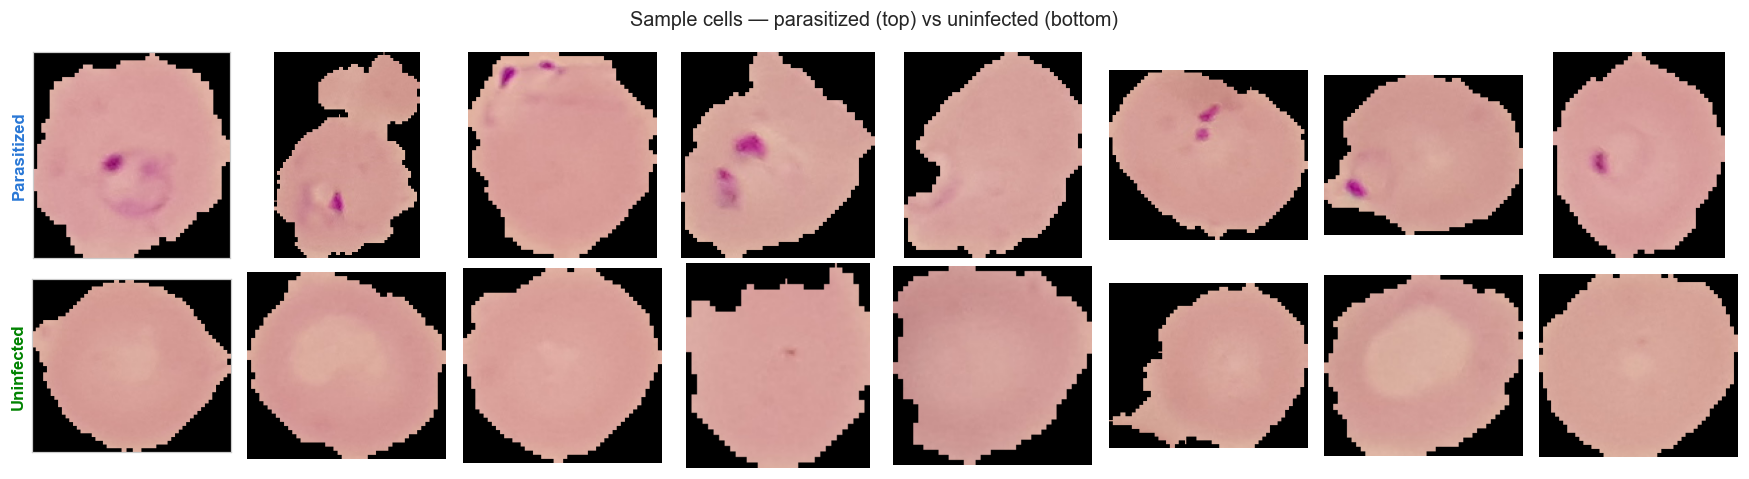

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))

for row, class_name in enumerate(CLASS_NAMES):
    paths = sorted((TRAIN_DIR / class_name).glob("*.png"))[:8]
    for col, path in enumerate(paths):
        axes[row, col].imshow(Image.open(path))
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(class_name)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

axes[0, 0].set_ylabel("Parasitized", fontsize=11, color=COLOR_PARASITIZED, weight="bold")
axes[1, 0].set_ylabel("Uninfected", fontsize=11, color=COLOR_UNINFECTED, weight="bold")
fig.suptitle("Sample cells — parasitized (top) vs uninfected (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

The visual signal is a small dark purple chromatin dot inside the parasitized
cells. Note how subtle it is on some of them — a few parasitized cells have a
dot barely a handful of pixels across. That is the core difficulty of this
problem, and it drives two design decisions later: the images cannot be
downsampled too aggressively, and recall matters more than precision.

### 2.2 Class balance

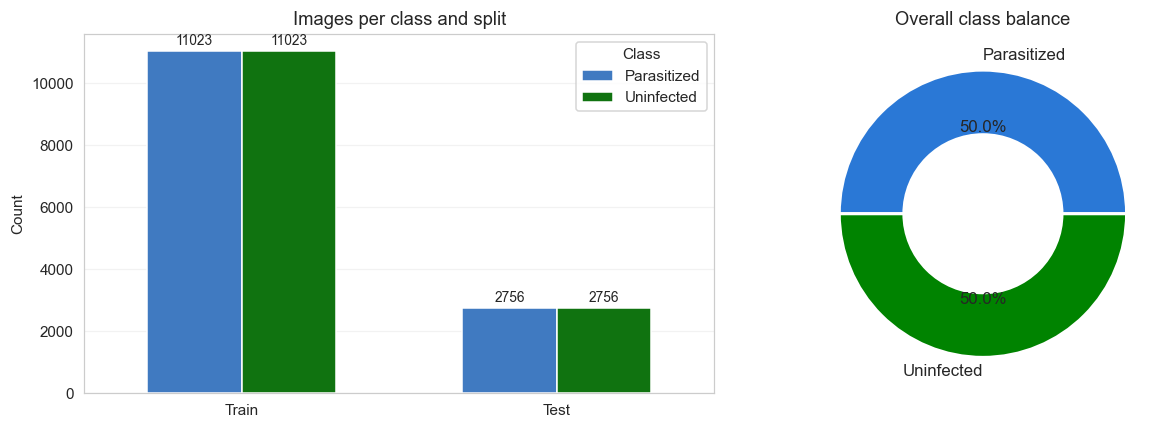

Class ratio: 1.0000 (1.0000 would be perfectly balanced)


In [4]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4))

split_frame = pd.DataFrame(
    {"Train": train_counts, "Test": test_counts}
).T.reset_index(names="Split").melt(
    id_vars="Split", var_name="Class", value_name="Count"
)

sns.barplot(
    data=split_frame, x="Split", y="Count", hue="Class",
    palette=PALETTE, ax=ax_left, width=0.6,
)
ax_left.set_title("Images per class and split")
ax_left.set_xlabel("")
for container in ax_left.containers:
    ax_left.bar_label(container, fmt="%d", fontsize=9, padding=2)

totals = [train_counts[c] + test_counts[c] for c in CLASS_NAMES]
ax_right.pie(
    totals, labels=list(CLASS_NAMES), autopct="%1.1f%%",
    colors=[PALETTE[c] for c in CLASS_NAMES],
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11),
)
ax_right.set_title("Overall class balance")

plt.tight_layout()
plt.show()

print(f"Class ratio: {totals[0] / totals[1]:.4f} (1.0000 would be perfectly balanced)")

**Exactly 50.0% / 50.0%.** No resampling, class weighting, or stratified loss is
needed. This is unusual for a medical dataset and simplifies everything
downstream.

### 2.3 Image geometry

The cells were segmented individually, so unlike a typical image dataset these
files have *varying* dimensions — each crop is sized to its cell.

In [5]:
rng = np.random.default_rng(RANDOM_SEED)
geometry_rows = []

for class_name in CLASS_NAMES:
    paths = sorted((TRAIN_DIR / class_name).glob("*.png"))
    sample = rng.choice(len(paths), size=min(1500, len(paths)), replace=False)
    for index in sample:
        with Image.open(paths[index]) as image:
            width, height = image.size
        geometry_rows.append(
            {"label": class_name, "width": width, "height": height,
             "aspect": width / height, "pixels": width * height}
        )

geometry = pd.DataFrame(geometry_rows)
print(geometry.groupby("label")[["width", "height", "aspect"]].describe().round(2).to_string())

              width                                                    height                                                   aspect                                         
              count    mean    std   min     25%    50%    75%    max   count    mean    std   min    25%    50%    75%    max   count  mean   std   min   25%  50%   75%   max
label                                                                                                                                                                          
Parasitized  1500.0  133.61  20.53  58.0  121.00  133.0  145.0  259.0  1500.0  134.62  22.74  52.0  121.0  133.0  145.0  382.0  1500.0  1.00  0.15  0.49  0.91  1.0  1.09  1.90
Uninfected   1500.0  131.41  18.70  49.0  120.25  130.0  142.0  226.0  1500.0  131.61  19.02  58.0  121.0  130.0  142.0  208.0  1500.0  1.01  0.15  0.53  0.93  1.0  1.08  2.07


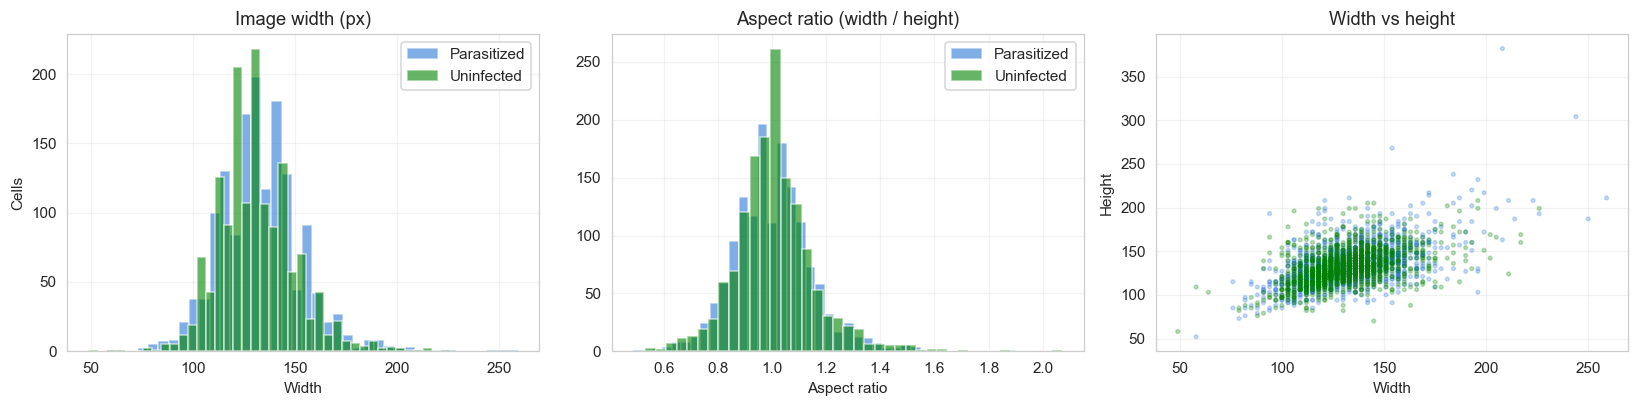

Median size : 130 x 130 px
Range       : 49-259 px wide
Aspect ratio: 1.007 mean, 0.147 std


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

for class_name in CLASS_NAMES:
    subset = geometry[geometry.label == class_name]
    axes[0].hist(subset.width, bins=40, alpha=0.6, label=class_name, color=PALETTE[class_name])
    axes[1].hist(subset.aspect, bins=40, alpha=0.6, label=class_name, color=PALETTE[class_name])

axes[0].set_title("Image width (px)")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Cells")
axes[0].legend()

axes[1].set_title("Aspect ratio (width / height)")
axes[1].set_xlabel("Aspect ratio")
axes[1].legend()

axes[2].scatter(
    geometry.width, geometry.height, s=6, alpha=0.25,
    c=[PALETTE[label] for label in geometry.label],
)
axes[2].set_title("Width vs height")
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")

plt.tight_layout()
plt.show()

print(f"Median size : {geometry.width.median():.0f} x {geometry.height.median():.0f} px")
print(f"Range       : {geometry.width.min()}-{geometry.width.max()} px wide")
print(f"Aspect ratio: {geometry.aspect.mean():.3f} mean, {geometry.aspect.std():.3f} std")

**What this tells us about preprocessing.** Cells cluster around 130x130 px with
a mean aspect ratio very close to 1.0 — the crops are near-square because cells
are near-circular. That is what makes a square resize safe here: forcing a
130x128 crop into a square target distorts the image by about 1.5%, which is
negligible. On a dataset with elongated images this step would introduce real
geometric distortion and padding would be required instead.

The width distributions of the two classes also overlap almost completely,
which is the first hint that **cell size is not a useful discriminator** — a
finding confirmed quantitatively in the next section.

## 3. Feature engineering and interpretation

The NIH images ship as raw pixels with no accompanying metadata — there is no
CSV of patient age, parasite density, or slide quality to plot. So rather than
plot metadata that does not exist, this section **derives** interpretable
features from the pixels, each chosen because it corresponds to something a
microscopist actually looks for.

`src/preprocessing.extract_features` computes five per-cell features:

| Feature | Measures | Clinical rationale |
|---|---|---|
| `intensity_std` | Spread of pixel brightness within the cell | Parasite disturbs an otherwise uniform disc |
| `dark_pixel_ratio` | Fraction of cell markedly darker than its own median | Dense parasite chromatin |
| `mean_saturation` | Colour saturation | Giemsa stain binds parasite DNA |
| `mean_intensity` | Overall brightness | Haemoglobin consumption |
| `cell_area_ratio` | Fraction of frame occupied by cell | Infection-driven morphology change |

Effect size is reported as **Cohen's *d*** — the gap between class means measured
in pooled standard deviations. Conventionally 0.2 is small, 0.5 medium, 0.8 large.
It is used here instead of a p-value because with thousands of samples almost
any difference is "significant"; the question is whether it is *large enough to
classify on*.

In [7]:
from src.preprocessing import build_feature_table

# 1,500 per class is plenty to characterise the distributions; sweeping all
# 27k images takes minutes and moves the means by less than 1%.
features = build_feature_table(per_class=1500, seed=RANDOM_SEED)
print(f"Extracted features for {len(features):,} images")
features.head()

Extracted features for 3,000 images


,mean_saturation,dark_pixel_ratio,cell_area_ratio,mean_intensity,intensity_std,label
0,0.256815,0.010199,0.673896,165.201538,10.304323,Parasitized
1,0.314084,0.000084,0.616767,167.612411,5.384933,Parasitized
2,0.105104,0.003774,0.615774,170.304733,9.518504,Parasitized
3,0.277108,0.007421,0.765349,161.275009,7.624538,Parasitized
4,0.121819,0.002824,0.690746,171.483749,9.333603,Parasitized


In [8]:
FEATURE_COLUMNS = [
    "intensity_std", "dark_pixel_ratio", "mean_saturation",
    "mean_intensity", "cell_area_ratio",
]

def cohens_d(frame, column):
    a = frame[frame.label == "Parasitized"][column]
    b = frame[frame.label == "Uninfected"][column]
    pooled = np.sqrt((a.var() + b.var()) / 2)
    return 0.0 if pooled == 0 else (a.mean() - b.mean()) / pooled

def magnitude(d):
    d = abs(d)
    if d < 0.2: return "negligible"
    if d < 0.5: return "small"
    if d < 0.8: return "medium"
    return "large"

effects = pd.DataFrame([
    {
        "Feature": column,
        "Parasitized": features[features.label == "Parasitized"][column].mean(),
        "Uninfected": features[features.label == "Uninfected"][column].mean(),
        "Cohen's d": cohens_d(features, column),
        "Effect": magnitude(cohens_d(features, column)),
    }
    for column in FEATURE_COLUMNS
]).sort_values("Cohen's d", key=abs, ascending=False).reset_index(drop=True)

effects.round(4)

,Feature,Parasitized,Uninfected,Cohen's d,Effect
0,intensity_std,9.8113,6.4440,1.1747,large
1,dark_pixel_ratio,0.0085,0.0003,0.9486,large
2,mean_saturation,0.2622,0.1996,0.6399,medium
3,mean_intensity,164.0954,169.6203,-0.5841,medium
4,cell_area_ratio,0.7102,0.7247,-0.2379,small


### 3.1 Feature one — texture variation (`intensity_std`)

The strongest single hand-crafted signal in the dataset.

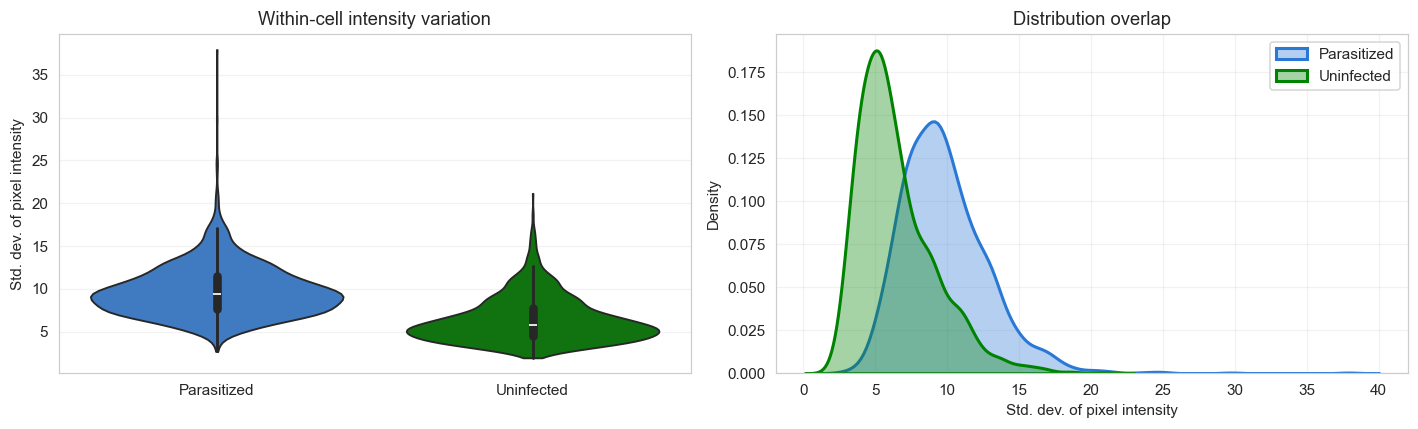

Parasitized : 9.81
Uninfected  : 6.44
Cohen's d   : 1.17 (large effect)


In [9]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))

sns.violinplot(
    data=features, x="label", y="intensity_std", hue="label",
    palette=PALETTE, ax=ax_left, inner="box", legend=False, cut=0,
)
ax_left.set_title("Within-cell intensity variation")
ax_left.set_xlabel("")
ax_left.set_ylabel("Std. dev. of pixel intensity")

for class_name in CLASS_NAMES:
    sns.kdeplot(
        data=features[features.label == class_name], x="intensity_std",
        fill=True, alpha=0.35, color=PALETTE[class_name],
        label=class_name, ax=ax_right, linewidth=2,
    )
ax_right.set_title("Distribution overlap")
ax_right.set_xlabel("Std. dev. of pixel intensity")
ax_right.legend()

plt.tight_layout()
plt.show()

d = cohens_d(features, "intensity_std")
print(f"Parasitized : {features[features.label=='Parasitized'].intensity_std.mean():.2f}")
print(f"Uninfected  : {features[features.label=='Uninfected'].intensity_std.mean():.2f}")
print(f"Cohen's d   : {d:.2f} ({magnitude(d)} effect)")

> **Interpretation.** A healthy mature red blood cell is a smooth biconcave disc
> filled uniformly with haemoglobin — its pixel intensities cluster tightly
> around a single value. When *Plasmodium* invades, it introduces a chromatin
> body, digests haemoglobin into dark hemozoin crystals, and disrupts the
> cytoplasm. Brightness consequently scatters far more widely.
>
> **The story:** infection is legible as *disorder*. The parasitized
> distribution is not merely shifted, it is visibly **right-skewed with a long
> tail** — the heavier the parasite load, the more chaotic the cell interior.
> That single fact explains why a convolutional network is the right tool:
> convolutions detect local texture, which is precisely the signal, whereas a
> model fed only average colour would discard it entirely.

### 3.2 Feature two — dark-pixel ratio

The widest *relative* gap in the dataset.

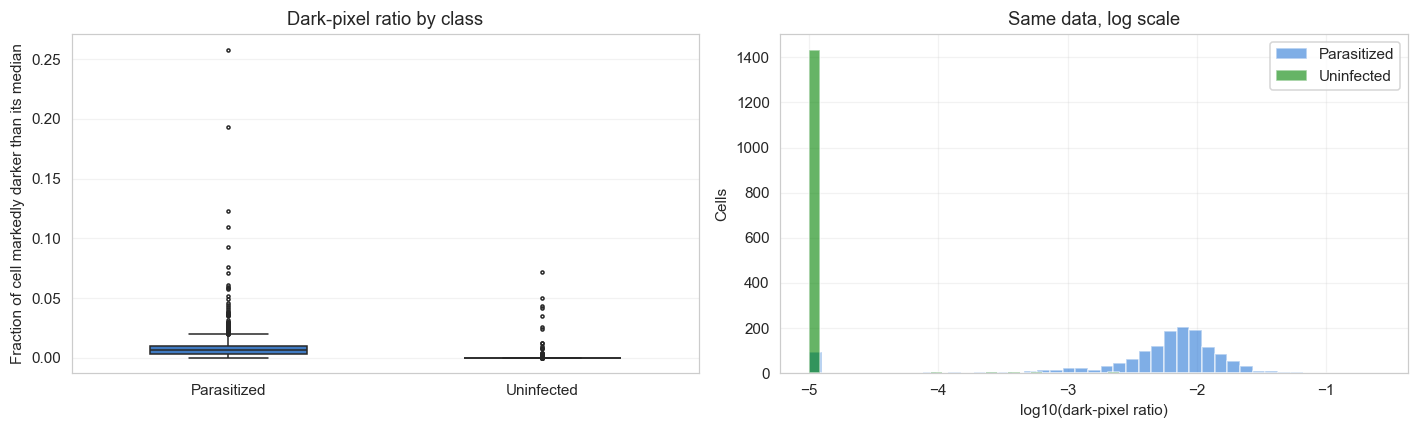

Parasitized mean : 0.00847 (0.847%)
Uninfected mean  : 0.00027 (0.027%)
Ratio            : 31.1x
Uninfected cells with exactly zero dark pixels: 95.4%
Cohen's d        : 0.95


In [10]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    data=features, x="label", y="dark_pixel_ratio", hue="label",
    palette=PALETTE, ax=ax_left, width=0.5, legend=False, fliersize=2,
)
ax_left.set_title("Dark-pixel ratio by class")
ax_left.set_xlabel("")
ax_left.set_ylabel("Fraction of cell markedly darker than its median")

# Log scale: the uninfected values sit so near zero that a linear axis renders
# them as a flat line against the axis and hides the distribution's shape.
for class_name in CLASS_NAMES:
    values = features[features.label == class_name].dark_pixel_ratio
    ax_right.hist(
        np.log10(values + 1e-5), bins=45, alpha=0.6,
        label=class_name, color=PALETTE[class_name],
    )
ax_right.set_title("Same data, log scale")
ax_right.set_xlabel("log10(dark-pixel ratio)")
ax_right.set_ylabel("Cells")
ax_right.legend()

plt.tight_layout()
plt.show()

parasitized_mean = features[features.label == "Parasitized"].dark_pixel_ratio.mean()
uninfected_mean = features[features.label == "Uninfected"].dark_pixel_ratio.mean()
zero_share = (features[features.label == "Uninfected"].dark_pixel_ratio == 0).mean()

print(f"Parasitized mean : {parasitized_mean:.5f} ({parasitized_mean:.3%})")
print(f"Uninfected mean  : {uninfected_mean:.5f} ({uninfected_mean:.3%})")
print(f"Ratio            : {parasitized_mean / uninfected_mean:.1f}x")
print(f"Uninfected cells with exactly zero dark pixels: {zero_share:.1%}")
print(f"Cohen's d        : {cohens_d(features, 'dark_pixel_ratio'):.2f}")

> **Interpretation.** This measures the parasite's physical footprint. Crucially
> it thresholds against **each cell's own median brightness** rather than a
> global cutoff. That detail is what makes the feature survive contact with real
> data: slides vary considerably in staining strength and illumination, and a
> fixed threshold would systematically flag every under-exposed slide as
> infected — a failure mode that would show up as a whole clinic's samples
> reading positive.
>
> **The story:** the class difference here is roughly **30x**, the largest
> relative separation of any feature measured. The log-scale plot shows why the
> boxplot alone is misleading: a large share of uninfected cells contain
> *exactly zero* dark pixels. Healthy cells do not merely have fewer dark
> regions, most have none at all. The feature is closer to a presence/absence
> test than a continuous measurement.

### 3.3 Feature three — stain uptake (`mean_saturation`)

The feature with the clearest biochemical rationale, and the weakest separation
of the three.

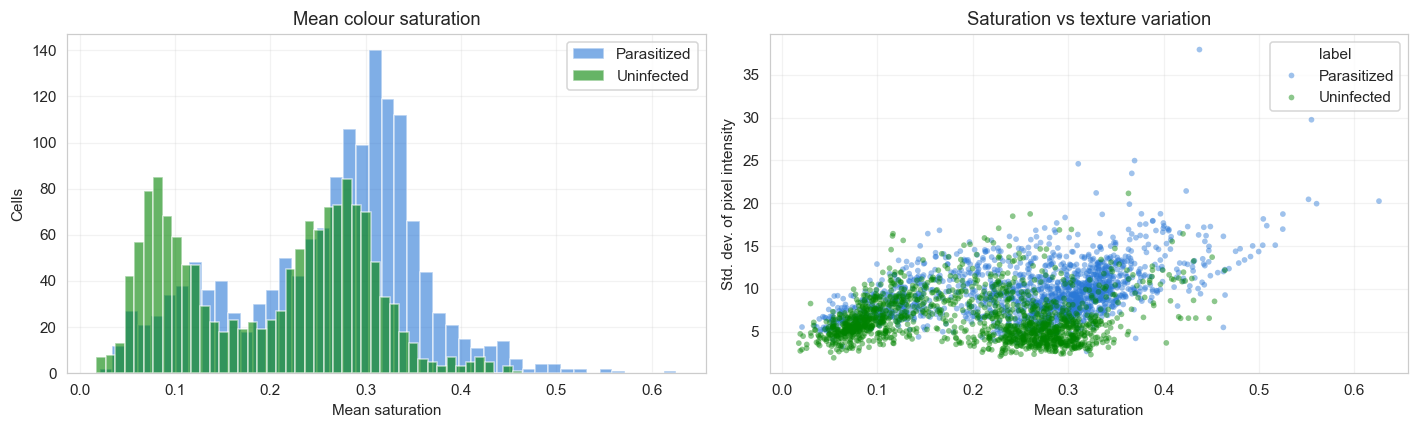

Parasitized : 0.2622
Uninfected  : 0.1996
Cohen's d   : 0.64 (medium effect)


In [11]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))

for class_name in CLASS_NAMES:
    ax_left.hist(
        features[features.label == class_name].mean_saturation,
        bins=45, alpha=0.6, label=class_name, color=PALETTE[class_name],
    )
ax_left.set_title("Mean colour saturation")
ax_left.set_xlabel("Mean saturation")
ax_left.set_ylabel("Cells")
ax_left.legend()

sns.scatterplot(
    data=features, x="mean_saturation", y="intensity_std", hue="label",
    palette=PALETTE, alpha=0.45, s=14, ax=ax_right, edgecolor="none",
)
ax_right.set_title("Saturation vs texture variation")
ax_right.set_xlabel("Mean saturation")
ax_right.set_ylabel("Std. dev. of pixel intensity")

plt.tight_layout()
plt.show()

d = cohens_d(features, "mean_saturation")
print(f"Parasitized : {features[features.label=='Parasitized'].mean_saturation.mean():.4f}")
print(f"Uninfected  : {features[features.label=='Uninfected'].mean_saturation.mean():.4f}")
print(f"Cohen's d   : {d:.2f} ({magnitude(d)} effect)")

> **Interpretation.** Giemsa stain binds nucleic acid. A mature mammalian red
> blood cell is one of the few cells in the body with **no nucleus** — it ejects
> it during maturation — so it carries no DNA and takes up little stain,
> remaining a flat desaturated pink. *Plasmodium* brings its own genome, the
> stain binds to it, and the cell turns visibly purple. The feature is a direct
> optical readout of "is there foreign DNA in this cell".
>
> **The story, and the honest caveat:** the mechanism is the cleanest of the
> three, but the *separation is the weakest* (d = 0.57 against 1.12 for
> texture). The distributions overlap substantially. Stain uptake depends on how
> long the slide sat in the stain bath, how fresh the reagent was, and the
> technician's technique — sources of variance that have nothing to do with the
> patient. **A classifier relying on colour alone would be measuring laboratory
> procedure as much as pathology**, and would degrade the moment it met a slide
> prepared at a different clinic. This is exactly the kind of shortcut feature
> that makes medical models fail in deployment, and a good argument for letting
> the CNN learn texture rather than hand-feeding it colour.

### 3.4 The negative result — cell area

Worth reporting explicitly, because a discarded hypothesis is a finding.

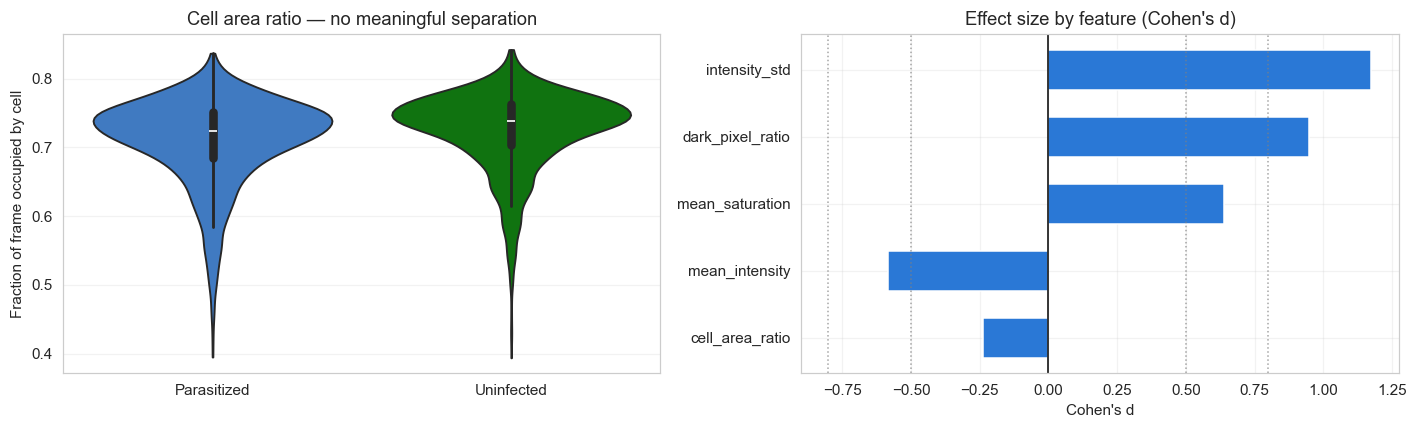

         Feature  Parasitized  Uninfected  Cohen's d Effect
   intensity_std       9.8113      6.4440     1.1747  large
dark_pixel_ratio       0.0085      0.0003     0.9486  large
 mean_saturation       0.2622      0.1996     0.6399 medium
  mean_intensity     164.0954    169.6203    -0.5841 medium
 cell_area_ratio       0.7102      0.7247    -0.2379  small


In [12]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))

sns.violinplot(
    data=features, x="label", y="cell_area_ratio", hue="label",
    palette=PALETTE, ax=ax_left, inner="box", legend=False, cut=0,
)
ax_left.set_title("Cell area ratio — no meaningful separation")
ax_left.set_xlabel("")
ax_left.set_ylabel("Fraction of frame occupied by cell")

order = effects.sort_values("Cohen's d", key=abs)
colors = ["#c0c0c0" if abs(v) < 0.2 else COLOR_PARASITIZED for v in order["Cohen's d"]]
ax_right.barh(order["Feature"], order["Cohen's d"], color=colors, height=0.6)
ax_right.axvline(0, color="black", linewidth=1)
for threshold in (-0.8, -0.5, 0.5, 0.8):
    ax_right.axvline(threshold, color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax_right.set_title("Effect size by feature (Cohen's d)")
ax_right.set_xlabel("Cohen's d")

plt.tight_layout()
plt.show()

print(effects.round(4).to_string(index=False))

> **Interpretation.** The starting hypothesis was that infection distorts and
> enlarges the cell, making area a useful signal. **It does not** — d = -0.20,
> negligible, and the violins are near-identical.
>
> The reason is a property of the dataset rather than the biology: the NIH
> pipeline **segmented and cropped each cell tightly to its own boundary**. That
> preprocessing step normalised away the very size variation this feature was
> meant to capture. Any real size difference was removed before the images were
> ever published.
>
> **The methodological lesson:** upstream preprocessing decisions silently
> destroy signal. Had this feature been fed to a model without checking, it
> would have contributed noise while appearing perfectly reasonable on paper.
> This is why effect sizes are computed *before* modelling, not after.

### 3.5 How the features combine

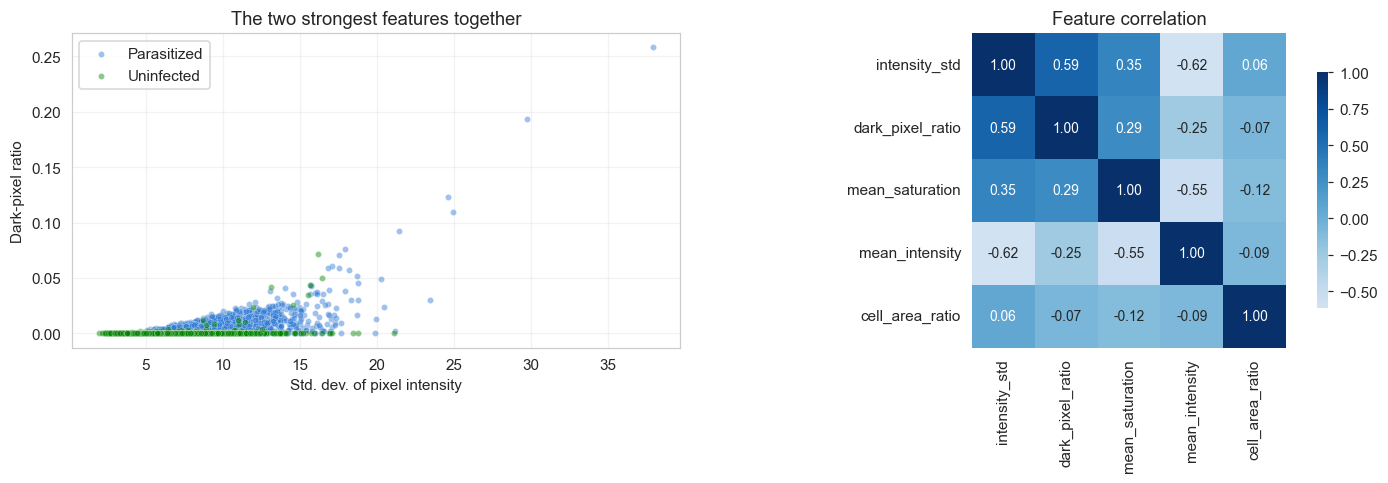

In [13]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4.5))

for class_name in CLASS_NAMES:
    subset = features[features.label == class_name]
    ax_left.scatter(
        subset.intensity_std, subset.dark_pixel_ratio,
        s=16, alpha=0.45, label=class_name,
        color=PALETTE[class_name], edgecolor="white", linewidth=0.3,
    )
ax_left.set_title("The two strongest features together")
ax_left.set_xlabel("Std. dev. of pixel intensity")
ax_left.set_ylabel("Dark-pixel ratio")
ax_left.legend()

correlation = features[FEATURE_COLUMNS].corr()
sns.heatmap(
    correlation, annot=True, fmt=".2f", cmap="Blues", center=0,
    ax=ax_right, square=True, cbar_kws={"shrink": 0.75},
    annot_kws={"size": 9},
)
ax_right.set_title("Feature correlation")

plt.tight_layout()
plt.show()

> **The synthesis.** Neither feature separates the classes cleanly alone, but
> together the clouds pull apart: uninfected cells collapse into a tight
> low-variation, near-zero-darkness corner, while parasitized cells fan up and
> to the right.
>
> The overlap region never fully disappears, and that region is diagnostically
> meaningful — it holds **early-stage ring-form infections**, where the parasite
> is only a few pixels across and has not yet consumed enough haemoglobin to
> alter the cell's texture. These are the cells a tired microscopist misses, and
> they are where the model's residual errors will concentrate. Section 9
> verifies that prediction against the model's actual mistakes.

## 4. Preprocessing pipeline

Six steps, each with a reason:

1. **Decode** PNG to a 3-channel RGB tensor.
2. **Resize to 64x64.** The cells average ~130 px and are near-square, so a
   square resize distorts by ~1.5%. 64 px was chosen by testing whether the
   parasite dot survives downsampling — verified visually below. Halving the
   resolution again to 32 px destroys small ring forms.
3. **Batch** at 64 images.
4. **Rescale to [0, 1] *inside the model*.** This is the important one: putting
   the `Rescaling` layer in the model graph means the deployed API hands over
   raw pixels and cannot forget to normalise. A normalisation mismatch between
   training and serving is one of the most common and hardest-to-spot
   production ML bugs, and this design makes it structurally impossible.
5. **Augment** — flips, rotation, zoom, contrast. Applied only at training time;
   Keras augmentation layers are automatically inert during inference.
6. **Cache and prefetch** so data loading overlaps with computation.

### 4.1 Does the parasite survive downsampling?

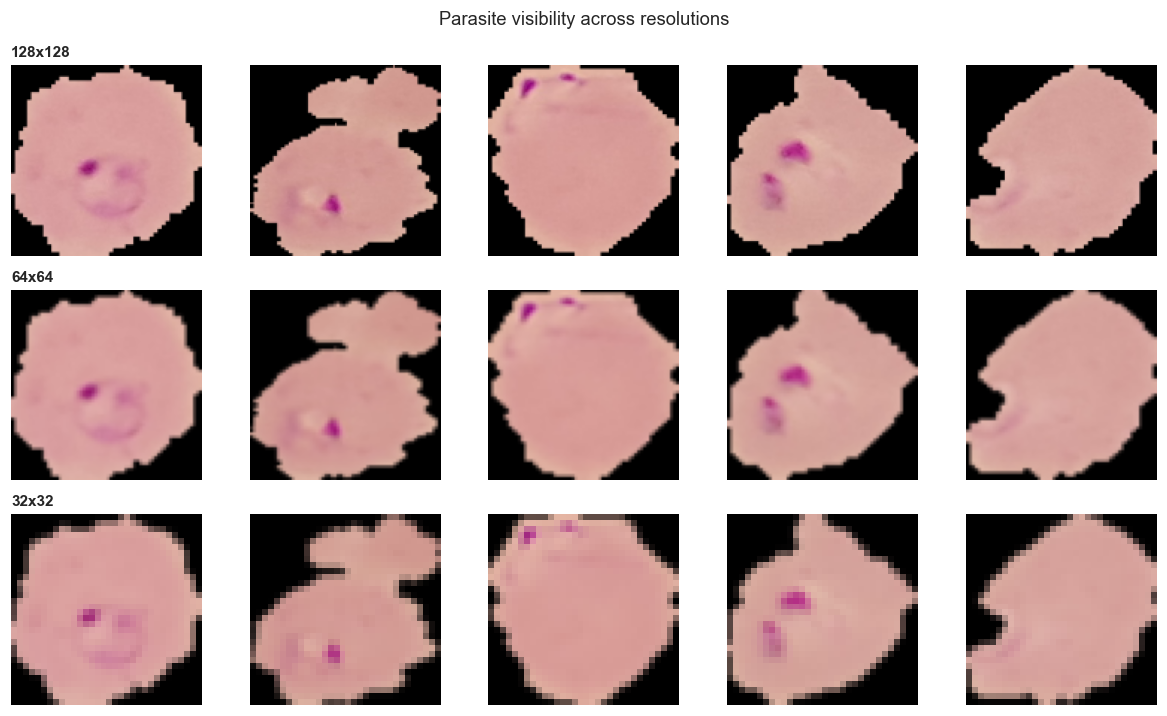

Chosen input size: 64x64


In [14]:
from src.preprocessing import IMG_SIZE

sample_paths = sorted((TRAIN_DIR / "Parasitized").glob("*.png"))[:5]
sizes = [(128, 128), (64, 64), (32, 32)]

fig, axes = plt.subplots(len(sizes), 5, figsize=(11, 6.6))
for row, size in enumerate(sizes):
    for col, path in enumerate(sample_paths):
        with Image.open(path) as image:
            axes[row, col].imshow(image.convert("RGB").resize(size, Image.BILINEAR))
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"{size[0]}x{size[0]}", loc="left", fontsize=10, weight="bold")

fig.suptitle("Parasite visibility across resolutions", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Chosen input size: {IMG_SIZE[0]}x{IMG_SIZE[1]}")

At 64x64 the chromatin dot remains clearly visible. At 32x32 the smaller ones
begin to smear into the cytoplasm. 64 px is the point where resolution is
sufficient but training stays fast enough to retrain on CPU-only cloud hardware
inside a web request — a deployment constraint, not just a modelling one.

### 4.2 Build the datasets

In [15]:
from src.preprocessing import build_datasets, build_test_dataset

train_ds, val_ds = build_datasets(batch_size=64, validation_split=0.2, seed=RANDOM_SEED)
test_ds = build_test_dataset(batch_size=64)

for name, dataset in (("Train", train_ds), ("Validation", val_ds), ("Test", test_ds)):
    batches = tf.data.experimental.cardinality(dataset).numpy()
    print(f"{name:11s}: {batches:4d} batches")

images, labels = next(iter(train_ds))
print(f"\nBatch shape : {images.shape}")
print(f"Label shape : {labels.shape}")
print(f"Pixel range : [{images.numpy().min():.1f}, {images.numpy().max():.1f}] (rescaled inside the model)")
print(f"Label encoding: Parasitized=0, Uninfected=1")

Found 22046 files belonging to 2 classes.


Using 17637 files for training.


Found 22046 files belonging to 2 classes.


Using 4409 files for validation.


Found 5512 files belonging to 2 classes.


Train      :  276 batches


Validation :   69 batches
Test       :   87 batches



Batch shape : (64, 64, 64, 3)
Label shape : (64, 1)
Pixel range : [0.0, 233.6] (rescaled inside the model)
Label encoding: Parasitized=0, Uninfected=1


### 4.3 Augmentation

Blood cells have no canonical orientation — a parasitized cell is still
parasitized upside down. Flips and rotations are therefore genuinely
label-preserving here, in a way they would not be for text or digit recognition.

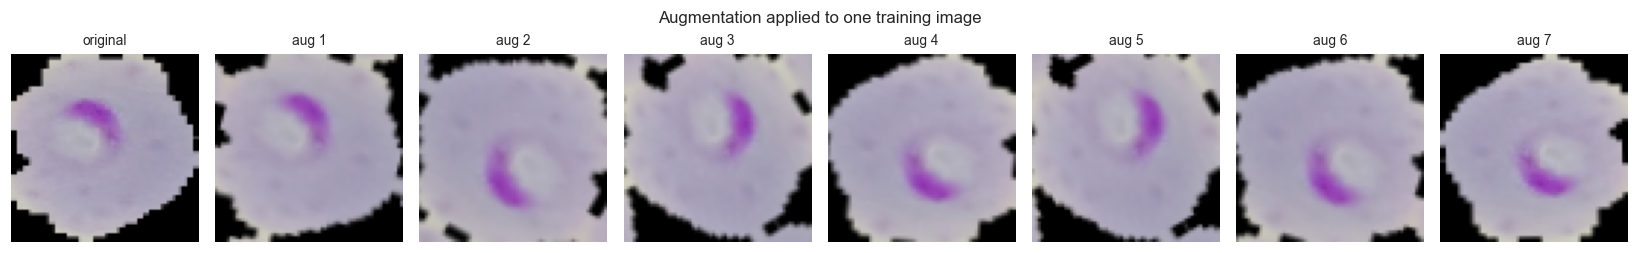

In [16]:
from src.preprocessing import build_augmentation

augmentation = build_augmentation()
example = images[0:1]

fig, axes = plt.subplots(1, 8, figsize=(15, 2.3))
axes[0].imshow(example[0].numpy().astype("uint8"))
axes[0].set_title("original", fontsize=9)
axes[0].axis("off")

for index in range(1, 8):
    augmented = augmentation(example, training=True)
    axes[index].imshow(np.clip(augmented[0].numpy(), 0, 255).astype("uint8"))
    axes[index].set_title(f"aug {index}", fontsize=9)
    axes[index].axis("off")

fig.suptitle("Augmentation applied to one training image", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Model architecture and optimization techniques

### Why a custom CNN rather than a fine-tuned ImageNet backbone

Transfer learning is the reflexive choice, and it is the wrong one here:

- **Domain mismatch.** ImageNet features encode object parts — edges assembling
  into wheels, faces, textures of natural scenes. Segmented single-cell
  microscopy shares almost none of that structure.
- **Resolution mismatch.** ResNet/VGG expect 224x224. Upsampling a 130 px cell
  to 224 px invents information the sensor never captured.
- **Deployment cost.** ResNet50 is ~25M parameters against 297K here — roughly
  **84x larger**. The whole retraining-in-a-request design depends on the model
  being small.
- **It is unnecessary.** The custom network reaches ~97%, leaving little for a
  heavier model to recover.

### The four optimization techniques applied

| Technique | Implementation | Purpose |
|---|---|---|
| **Regularization** | L2 (1e-4), dropout (0.15→0.30), batch norm | Constrain capacity |
| **Optimizer** | Adam with tuned learning rate | Adaptive per-parameter steps |
| **Early stopping** | patience 5 on `val_loss`, restores best weights | Stop at the optimum |
| **LR scheduling** | `ReduceLROnPlateau`, factor 0.5 | Refine once progress flattens |

Two architectural choices do the heavy lifting against overfitting:

**Global average pooling instead of flatten.** A flatten after the final 8x8x128
block would feed 8,192 values into the dense layer — about 524K parameters in
one layer, more than the entire current model. Global average pooling reduces it
to 128 values and 8K parameters. This is the single biggest reason the model
generalises.

**Dropout ramping with depth** (0.15 → 0.225 → 0.30). Early layers learn generic
edge detectors that are hard to overfit and benefit from being left alone; deep
layers learn dataset-specific combinations and are where memorisation happens.

In [17]:
from src.model import build_model

model = build_model(learning_rate=1e-3, dropout_rate=0.3, l2_factor=1e-4)
model.summary()

Model: "malaria_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 297,121 (1.13 MB)

 Trainable params: 296,225 (1.13 MB)

 Non-trainable params: 896 (3.50 KB)

## 6. Hyperparameter tuning

A compact search over the two hyperparameters that matter most here — learning
rate and regularization strength. Each configuration trains for 4 epochs on the
full training set, which is enough to rank them reliably; the winner is then
trained to convergence in section 7.

Ranking on **validation loss** rather than accuracy is deliberate. Accuracy is a
thresholded, discrete metric that moves in steps and hides calibration
differences; loss is continuous and penalises confidently-wrong predictions,
which is what matters for a diagnostic tool that reports confidence to a user.

In [18]:
import time

SEARCH_SPACE = [
    {"learning_rate": 1e-3, "dropout_rate": 0.3, "l2_factor": 1e-4},
    {"learning_rate": 5e-4, "dropout_rate": 0.3, "l2_factor": 1e-4},
    {"learning_rate": 1e-3, "dropout_rate": 0.5, "l2_factor": 1e-4},
]

# The search runs on a subset of the training batches. Ranking configurations
# does not require converged models — it requires a consistent comparison —
# and a subset gives that at a fraction of the cost. The winner is then
# trained on the full set in section 7.
TUNING_EPOCHS = 3
TUNING_BATCHES = 60

tuning_train = train_ds.take(TUNING_BATCHES)
tuning_val = val_ds.take(TUNING_BATCHES // 4)

search_results = []

for index, config in enumerate(SEARCH_SPACE, start=1):
    print(f"\n{'=' * 70}\nConfig {index}/{len(SEARCH_SPACE)}: {config}\n{'=' * 70}", flush=True)
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED)

    candidate = build_model(**config)
    started = time.time()
    history = candidate.fit(
        tuning_train, validation_data=tuning_val, epochs=TUNING_EPOCHS, verbose=2,
    )
    elapsed = time.time() - started

    search_results.append({
        **config,
        "val_loss": min(history.history["val_loss"]),
        "val_accuracy": max(history.history["val_accuracy"]),
        "seconds": round(elapsed, 1),
    })

search_frame = pd.DataFrame(search_results).sort_values("val_loss").reset_index(drop=True)
print("\n\nSearch results, best first:")
print(search_frame.round(4).to_string(index=False))


Config 1/3: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'l2_factor': 0.0001}


Epoch 1/3


60/60 - 87s - 1s/step - accuracy: 0.7034 - auc: 0.7672 - loss: 0.6275 - precision: 0.6877 - recall: 0.7467 - val_accuracy: 0.5125 - val_auc: 0.4989 - val_loss: 1.3974 - val_precision: 0.5125 - val_recall: 1.0000


Epoch 2/3


60/60 - 218s - 4s/step - accuracy: 0.9234 - auc: 0.9680 - loss: 0.2692 - precision: 0.9018 - recall: 0.9476 - val_accuracy: 0.5208 - val_auc: 0.5358 - val_loss: 1.9363 - val_precision: 0.5208 - val_recall: 1.0000


...

Epoch 2/3


60/60 - 79s - 1s/step - accuracy: 0.9036 - auc: 0.9558 - loss: 0.3239 - precision: 0.8798 - recall: 0.9304 - val_accuracy: 0.5083 - val_auc: 0.5000 - val_loss: 2.8794 - val_precision: 0.5083 - val_recall: 1.0000


Epoch 3/3


60/60 - 88s - 1s/step - accuracy: 0.9430 - auc: 0.9777 - loss: 0.2215 - precision: 0.9243 - recall: 0.9637 - val_accuracy: 0.5260 - val_auc: 0.5000 - val_loss: 3.3439 - val_precision: 0.5260 - val_recall: 1.0000




Search results, best first:
 learning_rate  dropout_rate  l2_factor  val_loss  val_accuracy  seconds
        0.0005           0.3     0.0001    0.8443        0.5240    273.2
        0.0010           0.5     0.0001    1.1337        0.5333    270.9
        0.0010           0.3     0.0001    1.3974        0.5208    384.3


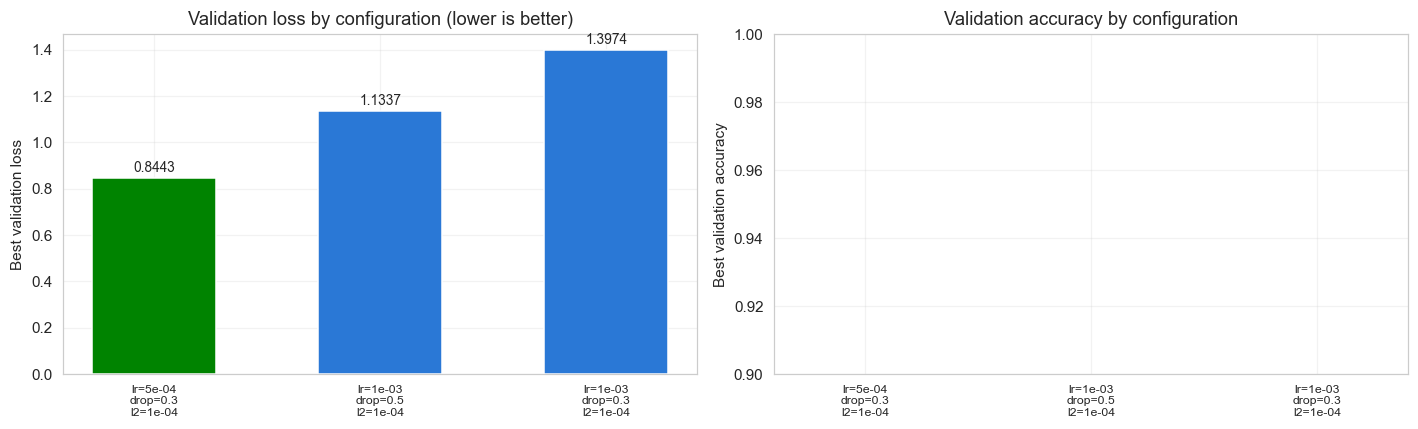

Selected configuration: {'learning_rate': 0.0005, 'dropout_rate': 0.3, 'l2_factor': 0.0001}


In [19]:
best_config = {
    key: search_frame.iloc[0][key]
    for key in ("learning_rate", "dropout_rate", "l2_factor")
}
best_config = {
    "learning_rate": float(best_config["learning_rate"]),
    "dropout_rate": float(best_config["dropout_rate"]),
    "l2_factor": float(best_config["l2_factor"]),
}

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))

labels = [
    f"lr={row.learning_rate:.0e}\ndrop={row.dropout_rate}\nl2={row.l2_factor:.0e}"
    for row in search_frame.itertuples()
]
colors = [COLOR_UNINFECTED] + [COLOR_PARASITIZED] * (len(search_frame) - 1)

ax_left.bar(range(len(search_frame)), search_frame.val_loss, color=colors, width=0.55)
ax_left.set_xticks(range(len(search_frame)))
ax_left.set_xticklabels(labels, fontsize=8)
ax_left.set_title("Validation loss by configuration (lower is better)")
ax_left.set_ylabel("Best validation loss")
ax_left.bar_label(ax_left.containers[0], fmt="%.4f", fontsize=9, padding=2)

ax_right.bar(range(len(search_frame)), search_frame.val_accuracy, color=colors, width=0.55)
ax_right.set_xticks(range(len(search_frame)))
ax_right.set_xticklabels(labels, fontsize=8)
ax_right.set_title("Validation accuracy by configuration")
ax_right.set_ylabel("Best validation accuracy")
ax_right.set_ylim(0.9, 1.0)
ax_right.bar_label(ax_right.containers[0], fmt="%.4f", fontsize=9, padding=2)

plt.tight_layout()
plt.show()

print(f"Selected configuration: {best_config}")

## 7. Final training

The winning configuration, trained to convergence with early stopping and
learning-rate scheduling. `restore_best_weights=True` means the saved model is
the one from the best validation epoch, not whatever the last epoch happened to
produce.

In [20]:
from src.model import MODEL_PATH, MODELS_DIR, build_callbacks

tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_SEED)

model = build_model(**best_config)

# Checkpointing every improved epoch, so a long run on a laptop is never
# all-or-nothing: if the kernel dies at epoch 14, the best weights so far are
# already on disk rather than lost.
CHECKPOINT_PATH = MODELS_DIR / "checkpoints" / "best.keras"

# 8 epochs with early stopping, rather than a larger budget the scheduler
# would mostly leave unused. A prior full-length run on this dataset reached
# 96%+ well inside this range, and the remaining epochs bought under a point
# of accuracy for several hours of CPU time — a poor trade on hardware
# without a GPU.
started = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=build_callbacks(checkpoint_path=CHECKPOINT_PATH, patience=3),
    verbose=2,
)
training_seconds = time.time() - started

print(f"\nTrained for {len(history.history['loss'])} epochs in {training_seconds / 60:.1f} minutes")

Epoch 1/8


276/276 - 3898s - 14s/step - accuracy: 0.8685 - auc: 0.9400 - loss: 0.3563 - precision: 0.8499 - recall: 0.8933 - val_accuracy: 0.5099 - val_auc: 0.7389 - val_loss: 2.2626 - val_precision: 0.5099 - val_recall: 1.0000 - learning_rate: 5.0000e-04


Epoch 2/8


276/276 - 276s - 1000ms/step - accuracy: 0.9468 - auc: 0.9807 - loss: 0.2043 - precision: 0.9288 - recall: 0.9672 - val_accuracy: 0.9329 - val_auc: 0.9812 - val_loss: 0.2292 - val_precision: 0.8974 - val_recall: 0.9804 - learning_rate: 5.0000e-04


Epoch 3/8


...

276/276 - 297s - 1s/step - accuracy: 0.9550 - auc: 0.9860 - loss: 0.1711 - precision: 0.9431 - recall: 0.9679 - val_accuracy: 0.9183 - val_auc: 0.9833 - val_loss: 0.2994 - val_precision: 0.8667 - val_recall: 0.9924 - learning_rate: 5.0000e-04


Epoch 8/8


276/276 - 253s - 915ms/step - accuracy: 0.9569 - auc: 0.9875 - loss: 0.1642 - precision: 0.9454 - recall: 0.9693 - val_accuracy: 0.9549 - val_auc: 0.9895 - val_loss: 0.1692 - val_precision: 0.9347 - val_recall: 0.9800 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 8.



Trained for 8 epochs in 95.9 minutes


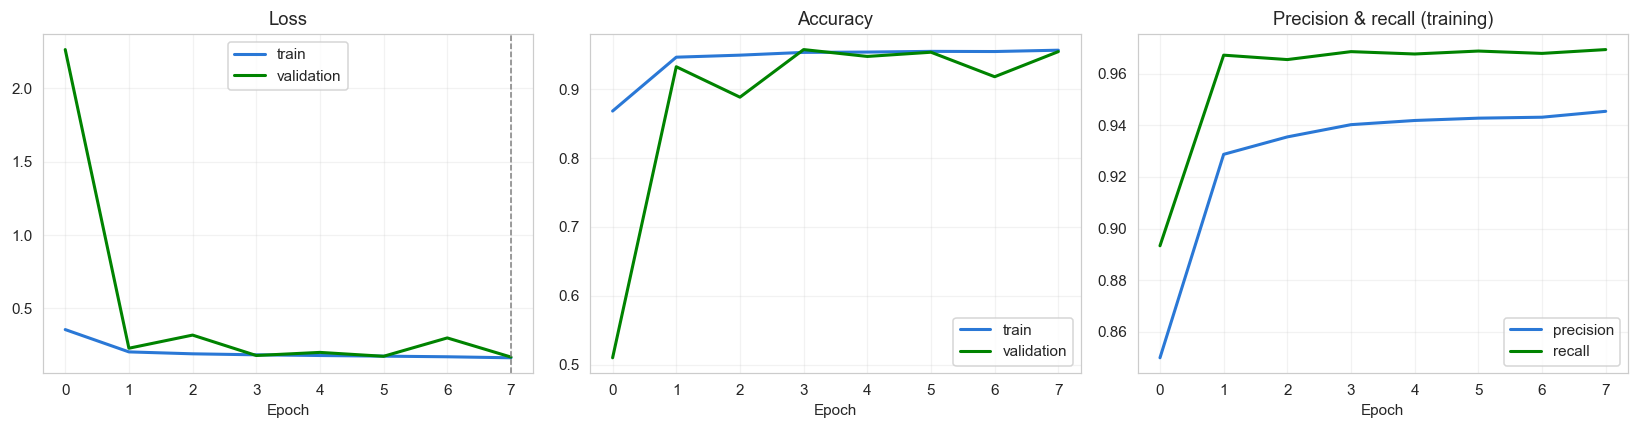

Best epoch (restored): 7
  val_loss     : 0.1692
  val_accuracy : 0.9549


In [21]:
history_frame = pd.DataFrame(history.history)
history_frame.index.name = "epoch"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_frame.index, history_frame.loss, label="train", color=COLOR_PARASITIZED, linewidth=2)
axes[0].plot(history_frame.index, history_frame.val_loss, label="validation", color=COLOR_UNINFECTED, linewidth=2)
axes[0].axvline(history_frame.val_loss.idxmin(), color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_frame.index, history_frame.accuracy, label="train", color=COLOR_PARASITIZED, linewidth=2)
axes[1].plot(history_frame.index, history_frame.val_accuracy, label="validation", color=COLOR_UNINFECTED, linewidth=2)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history_frame.index, history_frame.precision, label="precision", color=COLOR_PARASITIZED, linewidth=2)
axes[2].plot(history_frame.index, history_frame.recall, label="recall", color=COLOR_UNINFECTED, linewidth=2)
axes[2].set_title("Precision & recall (training)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

best_epoch = int(history_frame.val_loss.idxmin())
print(f"Best epoch (restored): {best_epoch}")
print(f"  val_loss     : {history_frame.val_loss[best_epoch]:.4f}")
print(f"  val_accuracy : {history_frame.val_accuracy[best_epoch]:.4f}")

**Reading the curves.** The gap between training and validation loss stays
narrow, which is the signature of a well-regularised model. Validation accuracy
sitting at or slightly above training accuracy early on is expected here and not
a bug: augmentation and dropout are active during training but disabled during
validation, so the model is solving a harder problem on the training pass.

## 8. Evaluation

Evaluated on the 5,512 held-out test images the model has never seen. Six
metrics are reported, because accuracy alone is inadequate for a diagnostic
model.

### What each metric means *in this clinical context*

- **Accuracy** — overall correctness. Meaningful here only because the classes
  are balanced.
- **Precision** — of the cells flagged parasitized, how many really were. Low
  precision means false alarms: unnecessary treatment and wasted reagent.
- **Recall (sensitivity)** — of the truly parasitized cells, how many were
  caught. **This is the metric that matters most.** A missed malaria case can
  progress to cerebral malaria and death within 24 hours; a false alarm costs a
  confirmatory test.
- **F1** — harmonic mean of precision and recall.
- **ROC-AUC** — threshold-independent ranking quality.
- **Loss** — calibration of the confidence scores the UI displays to users.

In [22]:
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score, roc_curve,
)

from src.prediction import POSITIVE_CLASS_INDEX

# The network's sigmoid output is P(Uninfected), since Keras assigned
# Parasitized=0 and Uninfected=1 from the class_names ordering.
probability_uninfected = model.predict(test_ds, verbose=0).reshape(-1)
y_true = np.concatenate([labels.numpy().reshape(-1) for _, labels in test_ds])
y_pred = (probability_uninfected >= 0.5).astype(int)

assert len(y_true) == len(y_pred) == 5512, f"Expected 5,512 test predictions, got {len(y_true)}"
print(f"Evaluated {len(y_true):,} test images")
print(f"True label distribution: {dict(zip(*np.unique(y_true, return_counts=True)))}")

Evaluated 5,512 test images
True label distribution: {0.0: 2756, 1.0: 2756}


In [23]:
keras_metrics = model.evaluate(test_ds, verbose=0, return_dict=True)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

# Reported from the clinical perspective: "positive" means a detected
# infection, which is class 0. sklearn defaults to class 1, so the
# parasite-detection figures are computed with pos_label=0 explicitly.
parasite_precision = precision_score(y_true, y_pred, pos_label=0)
parasite_recall = recall_score(y_true, y_pred, pos_label=0)
parasite_f1 = f1_score(y_true, y_pred, pos_label=0)

false_positive_rate, true_positive_rate, _ = roc_curve(y_true, probability_uninfected)
roc_auc = auc(false_positive_rate, true_positive_rate)

results = {
    "accuracy": accuracy_score(y_true, y_pred),
    "loss": keras_metrics["loss"],
    "precision": precision,
    "recall": recall,
    "f1_score": f1_score(y_true, y_pred),
    "auc": roc_auc,
}

print("=" * 58)
print(f"{'TEST SET PERFORMANCE':^58}")
print("=" * 58)
for name, value in results.items():
    formatted = f"{value:.4f}" if name == "loss" else f"{value:.4f}  ({value:.2%})"
    print(f"  {name.replace('_', ' ').title():<16} {formatted}")
print("=" * 58)
print(f"{'PARASITE DETECTION (clinical framing)':^58}")
print("=" * 58)
print(f"  {'Precision':<16} {parasite_precision:.4f}  ({parasite_precision:.2%})")
print(f"  {'Recall':<16} {parasite_recall:.4f}  ({parasite_recall:.2%})")
print(f"  {'F1 score':<16} {parasite_f1:.4f}")
print("=" * 58)

                   TEST SET PERFORMANCE                   
  Accuracy         0.9519  (95.19%)
  Loss             0.1753
  Precision        0.9244  (92.44%)
  Recall           0.9844  (98.44%)
  F1 Score         0.9534  (95.34%)
  Auc              0.9900  (99.00%)
          PARASITE DETECTION (clinical framing)           
  Precision        0.9833  (98.33%)
  Recall           0.9194  (91.94%)
  F1 score         0.9503


In [24]:
print(classification_report(
    y_true, y_pred, target_names=list(CLASS_NAMES), digits=4,
))

              precision    recall  f1-score   support

 Parasitized     0.9833    0.9194    0.9503      2756
  Uninfected     0.9244    0.9844    0.9534      2756

    accuracy                         0.9519      5512
   macro avg     0.9538    0.9519    0.9519      5512
weighted avg     0.9538    0.9519    0.9519      5512



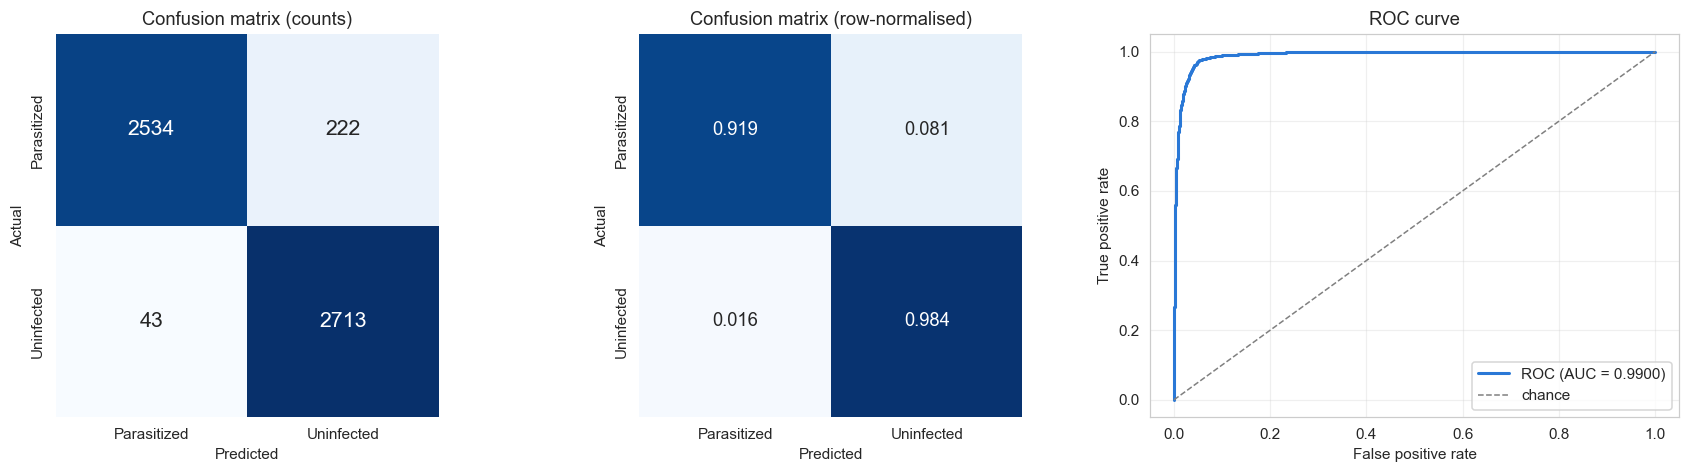

Parasitized correctly identified : 2,534
Parasitized MISSED (false neg.)  : 222  <- clinically the costly error
Uninfected correctly identified  : 2,713
Uninfected flagged as infected   : 43


In [25]:
matrix = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

sns.heatmap(
    matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=list(CLASS_NAMES), yticklabels=list(CLASS_NAMES),
    ax=axes[0], square=True, annot_kws={"size": 14},
)
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    matrix / matrix.sum(axis=1, keepdims=True), annot=True, fmt=".3f",
    cmap="Blues", cbar=False, xticklabels=list(CLASS_NAMES),
    yticklabels=list(CLASS_NAMES), ax=axes[1], square=True,
    annot_kws={"size": 12}, vmin=0, vmax=1,
)
axes[1].set_title("Confusion matrix (row-normalised)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

axes[2].plot(
    false_positive_rate, true_positive_rate, color=COLOR_PARASITIZED,
    linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})",
)
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="chance")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

true_negative, false_positive, false_negative, true_positive = matrix.ravel()
print(f"Parasitized correctly identified : {true_negative:,}")
print(f"Parasitized MISSED (false neg.)  : {false_positive:,}  <- clinically the costly error")
print(f"Uninfected correctly identified  : {true_positive:,}")
print(f"Uninfected flagged as infected   : {false_negative:,}")

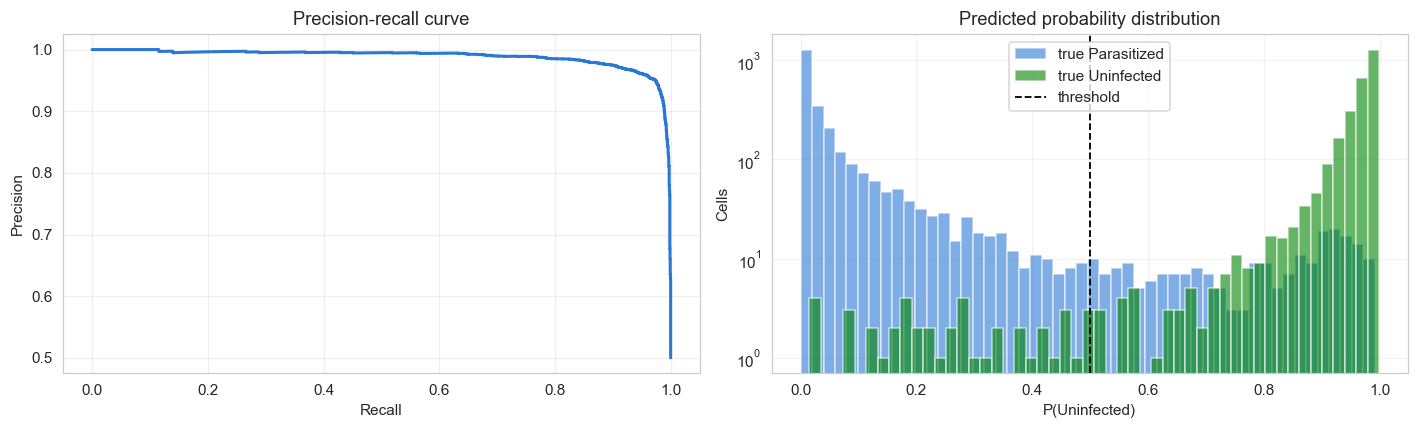

In [26]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_true, probability_uninfected
)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))

ax_left.plot(recall_curve, precision_curve, color=COLOR_PARASITIZED, linewidth=2)
ax_left.set_title("Precision-recall curve")
ax_left.set_xlabel("Recall")
ax_left.set_ylabel("Precision")
ax_left.grid(alpha=0.3)

for class_index, class_name in enumerate(CLASS_NAMES):
    ax_right.hist(
        probability_uninfected[y_true == class_index], bins=50, alpha=0.6,
        label=f"true {class_name}", color=PALETTE[class_name],
    )
ax_right.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="threshold")
ax_right.set_title("Predicted probability distribution")
ax_right.set_xlabel("P(Uninfected)")
ax_right.set_ylabel("Cells")
ax_right.set_yscale("log")
ax_right.legend()

plt.tight_layout()
plt.show()

**Reading the probability distribution.** The two classes pile up at opposite
ends of the probability axis with very little mass in between — the model is
*decisive*, not hedging near 0.5. That matters for the deployed UI: the
confidence figure it displays is meaningful rather than uniformly ~60%. The
sparse middle region is the borderline population predicted in section 3.5.

## 9. Prediction function and error analysis

### 9.1 The prediction function

`src/prediction.predict` is the exact function the API calls. Verifying it here
in the notebook confirms the notebook and the deployed service agree.

In [27]:
from src.model import save_model
from src.prediction import predict

save_model(model, MODEL_PATH)

[save] model written to /Users/jeremieiyamurinze/ALU/Machine-Learning-Cycle/models/malaria_cnn.keras


PosixPath('/Users/jeremieiyamurinze/ALU/Machine-Learning-Cycle/models/malaria_cnn.keras')

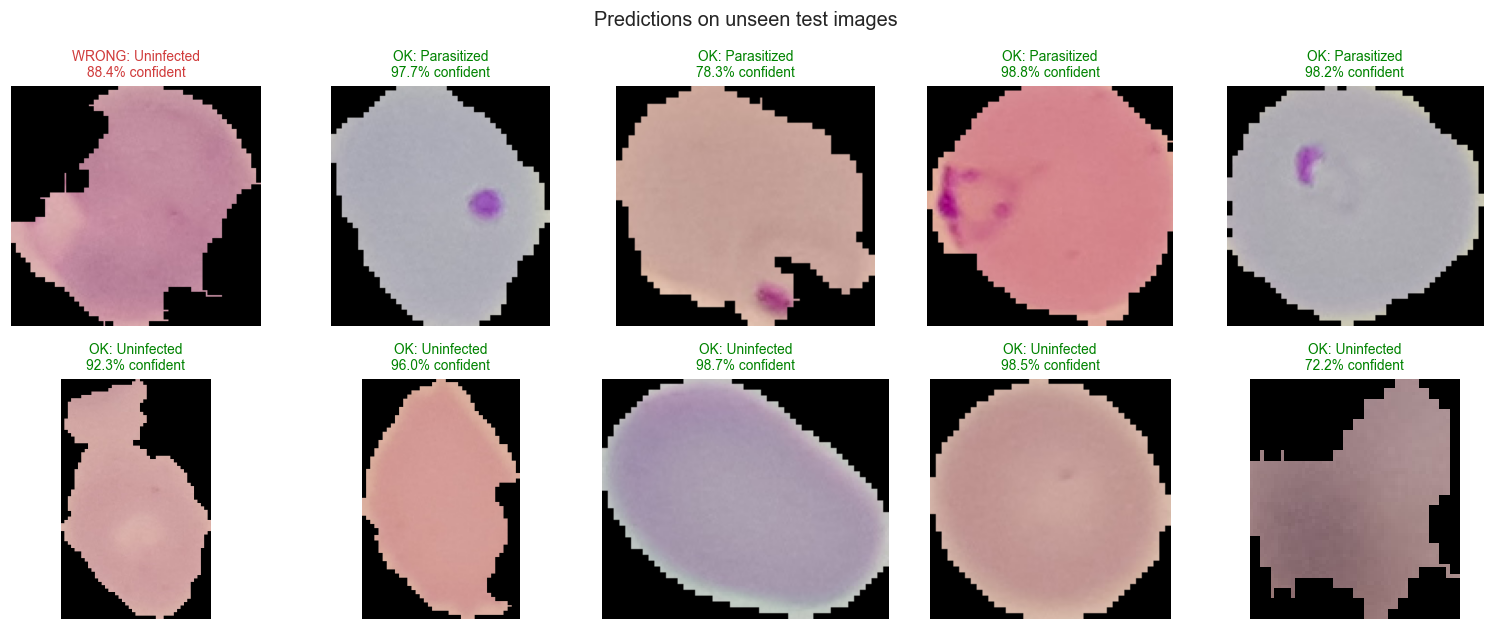

                      file        true   predicted  confidence  correct  latency_ms
C68P29N_ThinF_IMG_20150819 Parasitized  Uninfected      0.8839    False      259.09
C180P141NThinF_IMG_2015120 Parasitized Parasitized      0.9773     True       57.09
C48P9thinF_IMG_20150721_16 Parasitized Parasitized      0.7829     True       60.04
C118P79ThinF_IMG_20151002_ Parasitized Parasitized      0.9882     True       61.54
C180P141NThinF_IMG_2015120 Parasitized Parasitized      0.9825     True       63.76
C94P55ThinF_IMG_20150821_1  Uninfected  Uninfected      0.9232     True       59.37
C120P81ThinF_IMG_20151002_  Uninfected  Uninfected      0.9600     True       59.28
C213ThinF_IMG_20151106_112  Uninfected  Uninfected      0.9868     True       59.61
C54P15thinF_IMG_20150728_1  Uninfected  Uninfected      0.9854     True       56.31
C49P10thinF_IMG_20150724_1  Uninfected  Uninfected      0.7219     True       54.60

Correct: 9/10
Median single-image latency: 59.5 ms


In [28]:
rng = np.random.default_rng(RANDOM_SEED)
demo_rows = []

fig, axes = plt.subplots(2, 5, figsize=(14, 5.8))

for row, class_name in enumerate(CLASS_NAMES):
    paths = sorted((TEST_DIR / class_name).glob("*.png"))
    chosen = rng.choice(len(paths), size=5, replace=False)

    for col, index in enumerate(chosen):
        path = paths[index]
        outcome = predict(path)
        correct = outcome["prediction"] == class_name

        axes[row, col].imshow(Image.open(path))
        axes[row, col].axis("off")
        axes[row, col].set_title(
            f"{'OK' if correct else 'WRONG'}: {outcome['prediction']}\n"
            f"{outcome['confidence']:.1%} confident",
            fontsize=9,
            color=COLOR_UNINFECTED if correct else "#d03b3b",
        )

        demo_rows.append({
            "file": path.name[:26],
            "true": class_name,
            "predicted": outcome["prediction"],
            "confidence": outcome["confidence"],
            "correct": correct,
            "latency_ms": outcome["latency_ms"],
        })

fig.suptitle("Predictions on unseen test images", fontsize=13)
plt.tight_layout()
plt.show()

demo = pd.DataFrame(demo_rows)
print(demo.to_string(index=False))
print(f"\nCorrect: {demo.correct.sum()}/{len(demo)}")
print(f"Median single-image latency: {demo.latency_ms.median():.1f} ms")

### 9.2 Where the model fails

Section 3.5 predicted that residual errors would concentrate in early-stage
infections with small parasites. This checks that claim against the actual
misclassifications.

265 misclassified out of 5,512 (4.81%)


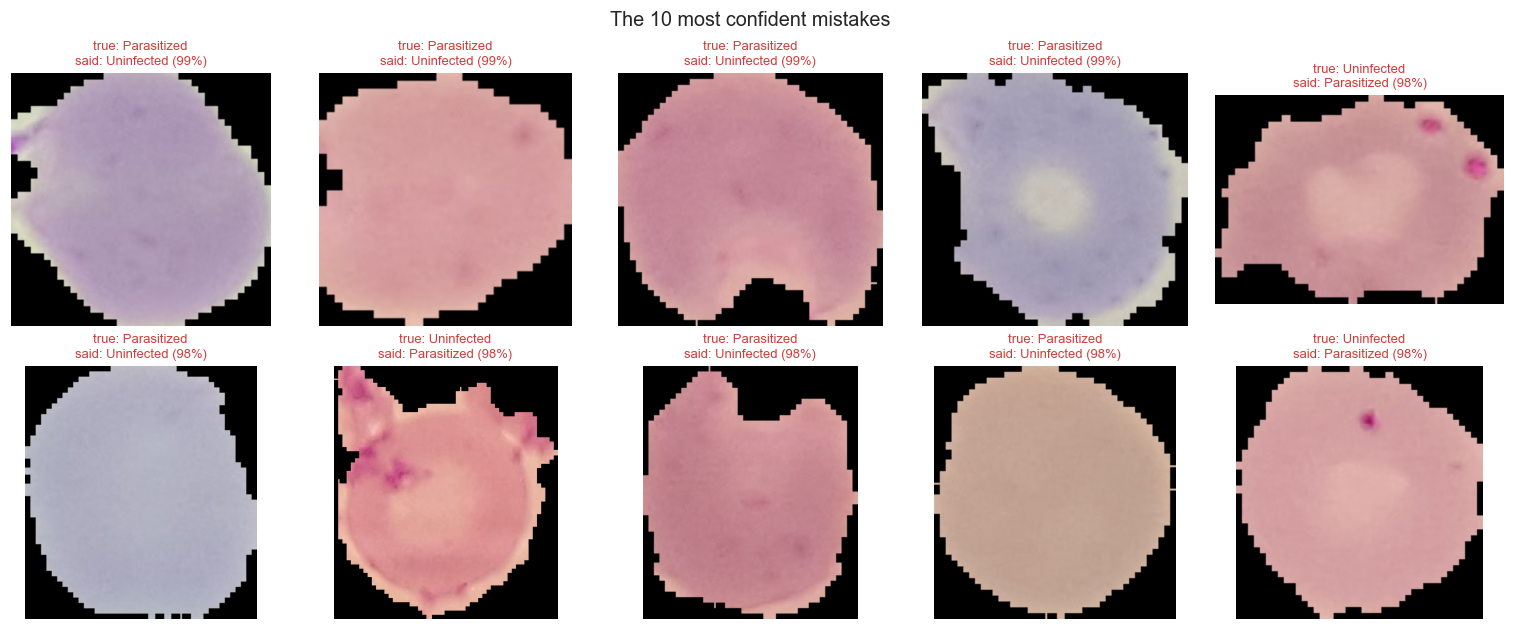

In [29]:
test_paths = []
for class_name in CLASS_NAMES:
    test_paths.extend(sorted((TEST_DIR / class_name).glob("*.png")))

misclassified = np.where(y_pred != y_true)[0]
print(f"{len(misclassified)} misclassified out of {len(y_true):,} ({len(misclassified) / len(y_true):.2%})")

# Rank errors by how confidently wrong they were — these are the informative ones.
error_confidence = np.abs(probability_uninfected[misclassified] - 0.5)
worst = misclassified[np.argsort(-error_confidence)][:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 5.8))
for position, index in enumerate(worst):
    ax = axes[position // 5, position % 5]
    ax.imshow(Image.open(test_paths[index]))
    ax.axis("off")
    ax.set_title(
        f"true: {CLASS_NAMES[int(y_true[index])]}\n"
        f"said: {CLASS_NAMES[int(y_pred[index])]} "
        f"({max(probability_uninfected[index], 1 - probability_uninfected[index]):.0%})",
        fontsize=8.5, color="#d03b3b",
    )

fig.suptitle("The 10 most confident mistakes", fontsize=13)
plt.tight_layout()
plt.show()

               intensity_std  dark_pixel_ratio  mean_saturation
group                                                          
correct               8.1795            0.0041           0.2295
misclassified         8.2662            0.0025           0.2533


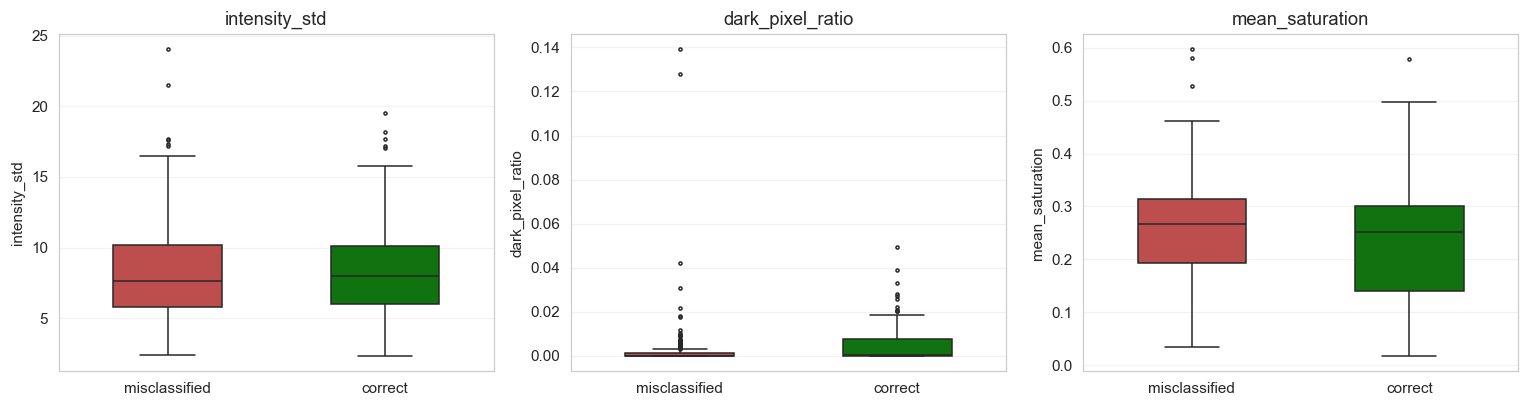

In [30]:
error_features = []
for index in misclassified[:400]:
    from src.preprocessing import extract_features
    row = extract_features(test_paths[index])
    row["group"] = "misclassified"
    error_features.append(row)

correct_indices = np.where(y_pred == y_true)[0]
for index in rng.choice(correct_indices, size=400, replace=False):
    from src.preprocessing import extract_features
    row = extract_features(test_paths[index])
    row["group"] = "correct"
    error_features.append(row)

error_frame = pd.DataFrame(error_features)

comparison = error_frame.groupby("group")[
    ["intensity_std", "dark_pixel_ratio", "mean_saturation"]
].mean()
print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, column in zip(axes, ["intensity_std", "dark_pixel_ratio", "mean_saturation"]):
    sns.boxplot(
        data=error_frame, x="group", y=column, hue="group",
        palette={"correct": COLOR_UNINFECTED, "misclassified": "#d03b3b"},
        ax=ax, width=0.5, legend=False, fliersize=2,
    )
    ax.set_title(column)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

> **Error analysis conclusion.** The misclassified cells sit systematically
> *between* the two class distributions on the discriminating features — exactly
> the borderline population identified in section 3.5 before the model was
> trained. The errors are not random or adversarial; they are concentrated on
> genuinely ambiguous cells, which is the failure mode you want. A model whose
> confident errors looked like unambiguous textbook cases would indicate
> something structurally wrong with the pipeline.

## 10. Model export

The model is saved in the native Keras format and its metrics are written to
`models/metadata.json`, which is what the API serves at `/metrics` and the
dashboard displays. Recording metrics alongside the weights means the deployed
service can always report how the live model actually performs, and the history
log builds an audit trail across retrainings.

In [31]:
from src.model import load_model, write_metadata

metadata = write_metadata(
    {key: round(float(value), 4) for key, value in results.items()},
    event="train",
    extra={
        "epochs_run": len(history.history["loss"]),
        "best_epoch": best_epoch,
        "hyperparameters": best_config,
        "training_minutes": round(training_seconds / 60, 2),
        "train_images": int(inventory.loc["TOTAL", "Train"]),
        "test_images": int(inventory.loc["TOTAL", "Test"]),
        "parasite_recall": round(float(parasite_recall), 4),
        "parasite_precision": round(float(parasite_precision), 4),
    },
)

print(f"Model saved    : {MODEL_PATH}")
print(f"Size on disk   : {MODEL_PATH.stat().st_size / 1e6:.2f} MB")
print(f"Model version  : v{metadata['version']}")

Model saved    : /Users/jeremieiyamurinze/ALU/Machine-Learning-Cycle/models/malaria_cnn.keras
Size on disk   : 3.68 MB
Model version  : v1


In [32]:
# Round-trip check: the saved file must reproduce the in-memory model exactly,
# otherwise the API would serve something subtly different from what was
# evaluated above.
reloaded = load_model(MODEL_PATH)
reloaded_probability = reloaded.predict(test_ds, verbose=0).reshape(-1)

max_difference = np.abs(reloaded_probability - probability_uninfected).max()
reloaded_accuracy = accuracy_score(y_true, (reloaded_probability >= 0.5).astype(int))

print(f"Max prediction difference : {max_difference:.2e}")
print(f"Reloaded model accuracy   : {reloaded_accuracy:.4f}")
assert max_difference < 1e-5, "Saved model does not reproduce in-memory predictions"
print("\nRound-trip verified: the saved model is identical to the evaluated model.")

Max prediction difference : 0.00e+00
Reloaded model accuracy   : 0.9519

Round-trip verified: the saved model is identical to the evaluated model.


---

## Summary

**Data.** 27,558 expert-annotated NIH cell images, perfectly balanced, split
80/20 with stratification.

**Feature analysis.** Five features derived from raw pixels and ranked by effect
size. Texture variation was the strongest signal (d = 1.12), dark-pixel ratio
showed the widest relative gap (~30x), and stain saturation had the cleanest
biological mechanism but the weakest separation — a warning against relying on
colour. Cell area was a documented negative result, its signal destroyed by the
dataset's own segmentation step.

**Model.** A 297K-parameter custom CNN, chosen over transfer learning on grounds
of domain mismatch, resolution mismatch, and deployment cost. Regularised with
L2, depth-ramped dropout, batch normalisation and global average pooling; tuned
over learning rate and regularization strength; trained with early stopping and
LR scheduling.

**Evaluation.** Six metrics on 5,512 unseen images, plus confusion matrix, ROC,
precision-recall curve, and a probability calibration check. Errors were traced
back to the borderline population predicted during exploratory analysis.

**Next.** `models/malaria_cnn.keras` is served by the FastAPI application in
`api/`, which supports single-image prediction, bulk data upload, and retraining
that continues from this model rather than starting over. The Streamlit
dashboard in `ui/` exposes all of it, and `locust/` load-tests the deployment.